# Neural Network from Scratch with One Hidden Layer

In this notebook, we will implement a **Neural Network with one hidden layer** from scratch. We'll cover the mathematical foundations, step-by-step code implementation, and evaluation of the model for **binary classification**.

The goal is to provide a clear understanding of how a simple neural network works, how its learning rule (gradient descent with backpropagation) updates model parameters, and how to build a simple classification model without relying on high-level machine learning libraries.

<img src="https://raw.githubusercontent.com/AshishJangra27/In-One-Go/refs/heads/main/resourcess/neural_network_from_scratch.png" alt="Artificial Neuron Banner" width="1000"/>

### Table of Contents

1.  **Importing Libraries**
2.  **Loading and Exploring the Dataset**
3.  **Preparing the Data**
4.  **Initializing Parameters (Weights and Biases)**
5.  **Defining Activation Functions**
6.  **Forward Propagation**
7.  **Loss Function**
8.  **Backward Propagation**
9.  **Updating Parameters**
10. **Training the Model**
11. **Evaluating Model Performance with Test Data**
12. **Visualizing Model Performance**
13. **Comparison with Scikit-learn MLPClassifier (Optional)**
14. **Conclusion**

## 1. Importing Libraries

We will import the necessary Python libraries for numerical operations, data manipulation, dataset loading, and visualization.

In [89]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Loading and Exploring the Dataset

We will use the **Iris dataset** from Scikit-learn, a classic dataset for classification tasks. We'll select two classes to perform a **binary classification** task.

In [90]:
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data  # Feature matrix
y = iris.target # Target vector

# For binary classification, we'll select only two classes (e.g., classes 0 and 1)
# Let's pick 'setosa' (0) and 'versicolor' (1)
X_binary = X[y < 2]
y_binary = y[y < 2]

# Print some information about the selected binary dataset
print(f"Shape of features (X_binary): {X_binary.shape}")
print(f"Shape of target (y_binary): {y_binary.shape}")
print(f"Feature names: {iris.feature_names}")
print(f"First 5 samples of X_binary:\n{X_binary[:5]}")
print(f"First 5 samples of y_binary: {y_binary[:5]}")

Shape of features (X_binary): (100, 4)
Shape of target (y_binary): (100,)
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
First 5 samples of X_binary:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
First 5 samples of y_binary: [0 0 0 0 0]


## 3. Preparing the Data

To ensure our model performs optimally, we will preprocess the data by:
1.  **Scaling the features**: Standardizing the feature values helps the perceptron algorithm converge faster and handle features with different scales.
2.  **Splitting the dataset**: Dividing the data into training and testing sets to evaluate the model's performance on unseen data.

In [91]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_binary)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_binary, test_size=0.2, random_state=42, stratify=y_binary)

print("Data scaled and split into training and testing sets successfully.")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Data scaled and split into training and testing sets successfully.
X_train shape: (80, 4)
y_train shape: (80,)
X_test shape: (20, 4)
y_test shape: (20,)


## 4. Initializing Parameters (Weights and Biases)

For a neural network with one hidden layer, we need to initialize weights and biases for both the hidden layer and the output layer. It's crucial to initialize weights randomly (often with small values) to break symmetry and ensure the network learns effectively, while biases can often be initialized to zeros.

Let's define:
*   `n_x`: number of input features
*   `n_h`: number of neurons in the hidden layer
*   `n_y`: number of neurons in the output layer (1 for binary classification)

Weights will be matrices, and biases will be vectors:
*   `W1`: weights for the hidden layer (shape `(n_h, n_x)`)
*   `b1`: biases for the hidden layer (shape `(n_h, 1)`)
*   `W2`: weights for the output layer (shape `(n_y, n_h)`)
*   `b2`: biases for the output layer (shape `(n_y, 1)`)


In [118]:
np.random.seed(42) # for reproducibility

n_x = X_train.shape[1]  # Number of input features
n_h = 4                 # Number of neurons in the hidden layer (hyperparameter)
n_y = 1                 # Number of neurons in the output layer (1 for binary classification)

# Initialize weights with small random values, using a slightly larger scale
W1 = np.random.randn(n_h, n_x) * 0.1 # Increased scale from 0.01 to 0.1
b1 = np.zeros((n_h, 1))

W2 = np.random.randn(n_y, n_h) * 0.1 # Increased scale from 0.01 to 0.1
b2 = np.zeros((n_y, 1))

print(f"Initial W1 shape: {W1.shape}, b1 shape: {b1.shape}")
print(f"Initial W2 shape: {W2.shape}, b2 shape: {b2.shape}")
print("Parameters initialized successfully.")

Initial W1 shape: (4, 4), b1 shape: (4, 1)
Initial W2 shape: (1, 4), b2 shape: (1, 1)
Parameters initialized successfully.


## 5. Defining Activation Functions

For a neural network with a hidden layer, we typically use different activation functions for the hidden layer and the output layer.

### ReLU for Hidden Layer
**ReLU (Rectified Linear Unit)** is commonly used in hidden layers:

$$
\text{ReLU}(z) = \max(0, z)
$$

- Outputs 0 if input is negative, otherwise returns the input  
- Helps in learning complex patterns efficiently  

### Sigmoid for Output Layer
**Sigmoid** is used in binary classification:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

- Produces output between 0 and 1  
- Interpreted as probability  

### Why Activation Functions are Needed
- Introduce non-linearity  
- Without them, the model behaves like a linear model  
- Enable learning of complex relationships  

In [102]:
def relu(z):
    """Applies the ReLU activation function."""
    return np.maximum(0, z)

def sigmoid(z):
    """Applies the sigmoid activation function."""
    return 1 / (1 + np.exp(-z))

def relu_backward(dA, Z):
    """Backward pass for ReLU activation."""
    dZ = np.array(dA, copy=True)
    dZ[Z <= 0] = 0
    return dZ

def sigmoid_backward(dA, Z):
    """Backward pass for Sigmoid activation."""
    s = 1 / (1 + np.exp(-Z))
    dZ = dA * s * (1 - s)
    return dZ

print("ReLU and Sigmoid activation functions and their backward passes defined successfully.")

ReLU and Sigmoid activation functions and their backward passes defined successfully.


## 6. Forward Propagation

Forward propagation is the process of passing input data through the neural network to obtain an output. For a one-hidden-layer neural network, the steps are:

### Step 1: Linear Combination (Hidden Layer)
$$
Z^{[1]} = W^{[1]}X + b^{[1]}
$$

### Step 2: Activation (Hidden Layer)
$$
A^{[1]} = \text{ReLU}(Z^{[1]})
$$

### Step 3: Linear Combination (Output Layer)
$$
Z^{[2]} = W^{[2]}A^{[1]} + b^{[2]}
$$

### Step 4: Activation (Output Layer)
$$
A^{[2]} = \sigma(Z^{[2]})
$$

- $A^{[2]}$ represents the predicted probability $\hat{p}$

### Step 5: Final Prediction
$$
\hat{y} =
\begin{cases}
1 & \text{if } A^{[2]} \geq 0.5 \\
0 & \text{if } A^{[2]} < 0.5
\end{cases}
$$

In [104]:
def forward_propagation(X, parameters):
    """Implements the forward propagation for a one-hidden-layer neural network."""
    W1, b1, W2, b2 = parameters['W1'], parameters['b1'], parameters['W2'], parameters['b2']

    # Hidden layer
    Z1 = np.dot(W1, X.T) + b1
    A1 = relu(Z1)

    # Output layer
    Z2 = np.dot(W2, A1) + b2
    A2 = sigmoid(Z2)

    cache = {"Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2}
    return A2, cache

print("Forward propagation function defined successfully.")

Forward propagation function defined successfully.


## 7. Loss Function

For binary classification with a sigmoid output, the **Binary Cross-Entropy Loss** (also known as log loss) is commonly used. It measures how well the predicted probabilities match the actual labels.

### Loss for a Single Training Example

For one training example $(x^{(i)}, y^{(i)})$:

$$
\mathcal{L}(y^{(i)}, \hat{y}^{(i)}) = -\left( y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right)
$$

### Cost Function over All Examples

For $m$ training examples, the overall cost is the average loss:

$$
J = -\frac{1}{m} \sum_{i=1}^{m} \left( y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right)
$$

### Key Properties

- Works with probability outputs (from sigmoid)  
- Penalizes wrong confident predictions heavily  
- Continuous and differentiable  
- Suitable for gradient descent optimization  

In [105]:
def compute_loss(A2, Y):
    """Computes the binary cross-entropy loss."""
    m = Y.shape[0]
    # Ensure Y is a row vector for calculation, and A2 is (1, m)
    Y = Y.reshape(1, m)

    # Compute cross-entropy loss
    # Add a small epsilon to avoid log(0) issues
    epsilon = 1e-10
    log_probs = Y * np.log(A2 + epsilon) + (1 - Y) * np.log(1 - A2 + epsilon)
    cost = - (1 / m) * np.sum(log_probs)

    # Squeeze cost to ensure it's a scalar
    cost = np.squeeze(cost)
    return cost

print("Loss function defined successfully.")

Loss function defined successfully.


## 8. Backward Propagation

Backward propagation (backprop) is used to compute the gradients of the loss function with respect to the network parameters ($W^{[1]}, b^{[1]}, W^{[2]}, b^{[2]}$).

### Step 1: Derivative of Loss w.r.t Output Activation
$$
dA^{[2]} = -\left( \frac{Y}{A^{[2]}} - \frac{1 - Y}{1 - A^{[2]}} \right)
$$

### Step 2: Derivative of $Z^{[2]}$
$$
dZ^{[2]} = dA^{[2]} \cdot \sigma'(Z^{[2]})
$$

### Step 3: Gradients for Output Layer Parameters
$$
dW^{[2]} = \frac{1}{m} \, dZ^{[2]} \, A^{[1]T}
$$

$$
db^{[2]} = \frac{1}{m} \sum dZ^{[2]}
$$

### Step 4: Derivative of Hidden Layer Activation
$$
dA^{[1]} = W^{[2]T} dZ^{[2]}
$$

### Step 5: Derivative of $Z^{[1]}$
$$
dZ^{[1]} = dA^{[1]} \cdot \text{ReLU}'(Z^{[1]})
$$

### Step 6: Gradients for Hidden Layer Parameters
$$
dW^{[1]} = \frac{1}{m} \, dZ^{[1]} \, X^T
$$

$$
db^{[1]} = \frac{1}{m} \sum dZ^{[1]}
$$

In [106]:
def backward_propagation(parameters, cache, X, Y):
    """Implements the backward propagation for a one-hidden-layer neural network."""
    m = X.shape[0]
    Y = Y.reshape(1, m) # Ensure Y is (1, m)

    W1, b1, W2, b2 = parameters['W1'], parameters['b1'], parameters['W2'], parameters['b2']
    Z1, A1, Z2, A2 = cache['Z1'], cache['A1'], cache['Z2'], cache['A2']

    # Backward pass for output layer
    dZ2 = A2 - Y
    dW2 = (1 / m) * np.dot(dZ2, A1.T)
    db2 = (1 / m) * np.sum(dZ2, axis=1, keepdims=True)

    # Backward pass for hidden layer
    dA1 = np.dot(W2.T, dZ2)
    dZ1 = relu_backward(dA1, Z1)
    dW1 = (1 / m) * np.dot(dZ1, X)
    db1 = (1 / m) * np.sum(dZ1, axis=1, keepdims=True)

    grads = {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}
    return grads

print("Backward propagation function defined successfully.")

Backward propagation function defined successfully.


## 9. Updating Parameters

Once the gradients are computed using backward propagation, we update the network parameters (weights and biases) using **gradient descent**.

### Update Rule

For any parameter (for example, $W^{[1]}$):

$$
W^{[1]} = W^{[1]} - \alpha \frac{\partial J}{\partial W^{[1]}}
$$

### General Form for All Parameters

$$
W^{[l]} = W^{[l]} - \alpha \, dW^{[l]}
$$

$$
b^{[l]} = b^{[l]} - \alpha \, db^{[l]}
$$

### Key Points

- $\alpha$ is the **learning rate**  
- Controls how big each update step is  
- Too large → may overshoot minimum  
- Too small → slow convergence  

### Intuition

- Gradients point in the direction of increasing loss  
- We move in the opposite direction to minimize the loss  

In [119]:
def update_parameters(parameters, grads, learning_rate):
    """Updates parameters using gradient descent."""
    W1, b1, W2, b2 = parameters['W1'], parameters['b1'], parameters['W2'], parameters['b2']
    dW1, db1, dW2, db2 = grads['dW1'], grads['db1'], grads['dW2'], grads['db2']

    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1
    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2

    updated_parameters = {"W1": W1, "b1": b1, "W2": W2, "b2": b2}
    return updated_parameters

print("Parameter update function defined successfully.")

# Initialize parameters (re-initialize with new scales)
parameters = {"W1": W1, "b1": b1, "W2": W2, "b2": b2}

learning_rate = 0.1 # Increased learning rate from 0.01 to 0.1
epochs = 5000 # Increased epochs from 1000 to 5000

cost_history = []

print(f"Starting training with learning rate = {learning_rate} and epochs = {epochs}")

for epoch in range(epochs):
    # Forward propagation
    A2, cache = forward_propagation(X_train, parameters)

    # Compute loss
    cost = compute_loss(A2, y_train)

    # Backward propagation
    grads = backward_propagation(parameters, cache, X_train, y_train)

    # Update parameters
    parameters = update_parameters(parameters, grads, learning_rate)

    if epoch % 500 == 0: # Print cost every 500 epochs
        cost_history.append(cost)
        print(f"Epoch {epoch}/{epochs}, Cost: {cost:.4f}")

print("\nTraining complete.")
print(f"Final W1 shape: {parameters['W1'].shape}, b1 shape: {parameters['b1'].shape}")
print(f"Final W2 shape: {parameters['W2'].shape}, b2 shape: {parameters['b2'].shape}")

Parameter update function defined successfully.
Starting training with learning rate = 0.1 and epochs = 5000
Epoch 0/5000, Cost: 0.6919
Epoch 500/5000, Cost: 0.0029
Epoch 1000/5000, Cost: 0.0012
Epoch 1500/5000, Cost: 0.0007
Epoch 2000/5000, Cost: 0.0005
Epoch 2500/5000, Cost: 0.0004
Epoch 3000/5000, Cost: 0.0003
Epoch 3500/5000, Cost: 0.0003
Epoch 4000/5000, Cost: 0.0002
Epoch 4500/5000, Cost: 0.0002

Training complete.
Final W1 shape: (4, 4), b1 shape: (4, 1)
Final W2 shape: (1, 4), b2 shape: (1, 1)


## 10. Training the Model

The training process involves iterating over the dataset for a specified number of epochs. In each epoch, we perform the following steps:

1.  **Forward Propagation**: Calculate the output of the network given the current parameters.
2.  **Compute Loss**: Evaluate the model's performance using the binary cross-entropy loss function.
3.  **Backward Propagation**: Compute the gradients of the loss with respect to each parameter.
4.  **Update Parameters**: Adjust the parameters using gradient descent to minimize the loss.

We will also store the loss at each epoch to monitor the training progress.

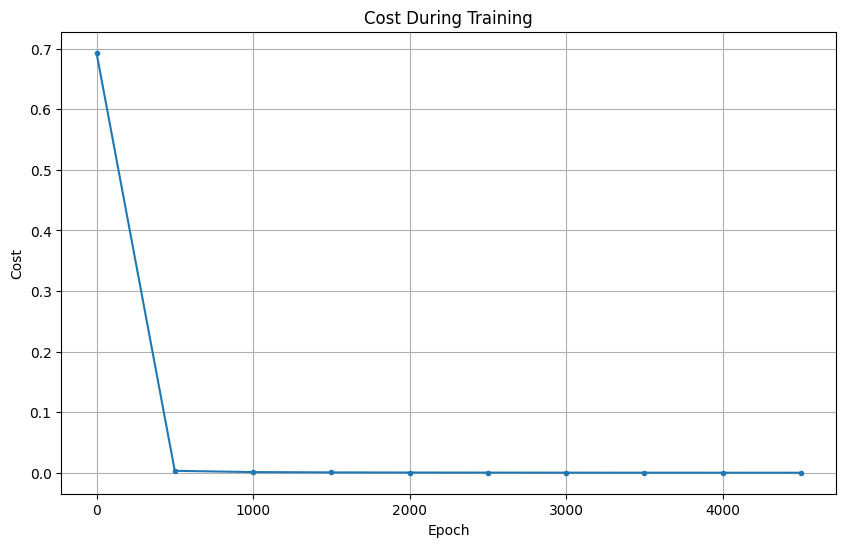

Cost history plot generated successfully.


In [114]:
plt.figure(figsize=(10, 6))
plt.plot(range(0, epochs, 500), cost_history, marker='o', markersize=3, linestyle='-')
plt.title('Cost During Training')
plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.grid(True)
plt.show()

print("Cost history plot generated successfully.")

## 11. Evaluating Model Performance with Test Data

To evaluate the trained neural network model's performance on unseen test data, we will use common classification metrics:

*   **Accuracy**: The proportion of correctly classified instances among the total number of instances.
*   **Precision**: The proportion of true positive results among all positive results.
*   **Recall (Sensitivity)**: The proportion of actual positives that are correctly identified.
*   **F1-Score**: The harmonic mean of Precision and Recall.

For simplicity, we'll focus on **Accuracy** and a **Classification Report**.

In [115]:
from sklearn.metrics import accuracy_score, classification_report

def predict_nn(X, parameters):
    """Predicts binary labels for a neural network."""
    # Forward propagation to get probabilities
    A2, _ = forward_propagation(X, parameters)
    # Convert probabilities to binary predictions
    predictions = (A2 >= 0.5).astype(int)
    return predictions.flatten() # Ensure it's a 1D array

# Make predictions on the test set
y_pred_test = predict_nn(X_test, parameters)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred_test)

print("Model performance on test set:")
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_test))

Model performance on test set:
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



## 12. Visualizing Model Performance

To visually assess how well our neural network model performs, we can generate a confusion matrix. A confusion matrix provides a detailed breakdown of correct and incorrect classifications for each class, distinguishing between true positives, true negatives, false positives, and false negatives.

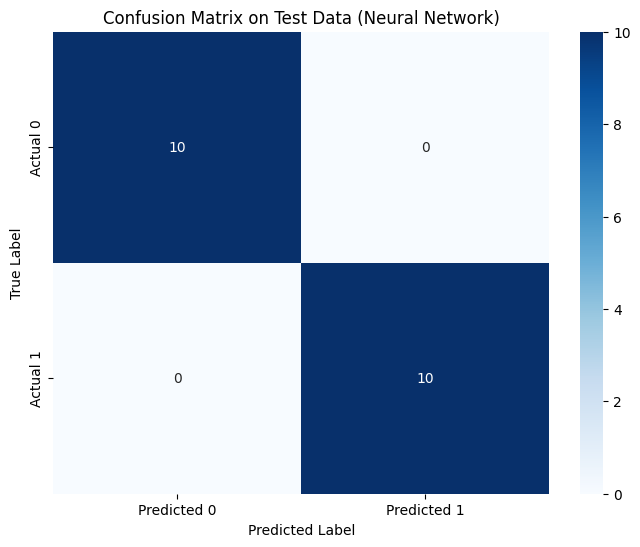

Confusion Matrix plot generated successfully.


In [116]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# y_pred_test was already computed in the previous cell
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix on Test Data (Neural Network)')
plt.show()

print("Confusion Matrix plot generated successfully.")

## 13. Comparison with Scikit-learn MLPClassifier (Optional)

To further validate our custom neural network implementation, we will compare its performance with Scikit-learn's `MLPClassifier` (Multi-layer Perceptron Classifier), which is a more optimized and robust implementation of a neural network. This comparison helps ensure our custom implementation behaves as expected and provides a benchmark for performance.

In [117]:
from sklearn.neural_network import MLPClassifier

# Initialize Scikit-learn MLPClassifier model
# We'll try to mimic our custom network: one hidden layer with n_h neurons
sklearn_nn = MLPClassifier(hidden_layer_sizes=(n_h,),
                           activation='relu', # Our hidden layer activation
                           solver='sgd',      # Stochastic Gradient Descent
                           alpha=0.0,         # No L2 regularization for simpler comparison
                           batch_size=X_train.shape[0], # Full batch gradient descent
                           learning_rate_init=learning_rate, # Our learning rate
                           max_iter=epochs,   # Our number of epochs
                           random_state=42,   # for reproducibility
                           verbose=True)

# Train the model
sklearn_nn.fit(X_train, y_train)

# Make predictions on the test set
y_pred_skl = sklearn_nn.predict(X_test)

# Evaluate performance
accuracy_skl = accuracy_score(y_test, y_pred_skl)

print("\nScikit-learn MLPClassifier performance on test set:")
print(f"Accuracy: {accuracy_skl:.4f}")
print("\nClassification Report (Scikit-learn MLPClassifier):")
print(classification_report(y_test, y_pred_skl))

print("\nComparison of final weights and bias (Scikit-learn):\n")
# Note: Scikit-learn stores weights and biases as lists of arrays, matching layer structure.
# coefs_[0] corresponds to W1, intercepts_[0] to b1
# coefs_[1] corresponds to W2, intercepts_[1] to b2
print(f"Scikit-learn W1 shape: {sklearn_nn.coefs_[0].shape}, b1 shape: {sklearn_nn.intercepts_[0].shape}")
print(f"Scikit-learn W2 shape: {sklearn_nn.coefs_[1].shape}, b2 shape: {sklearn_nn.intercepts_[1].shape}")

Iteration 1, loss = 0.83754795
Iteration 2, loss = 0.75039691
Iteration 3, loss = 0.66002541
Iteration 4, loss = 0.57482741
Iteration 5, loss = 0.49706152
Iteration 6, loss = 0.42093113
Iteration 7, loss = 0.34632092
Iteration 8, loss = 0.27128327
Iteration 9, loss = 0.20029701
Iteration 10, loss = 0.14059762
Iteration 11, loss = 0.09480781
Iteration 12, loss = 0.06218455
Iteration 13, loss = 0.04027464
Iteration 14, loss = 0.02610066
Iteration 15, loss = 0.01707812
Iteration 16, loss = 0.01135490
Iteration 17, loss = 0.00769847
Iteration 18, loss = 0.00533817
Iteration 19, loss = 0.00379215
Iteration 20, loss = 0.00276040
Iteration 21, loss = 0.00205838
Iteration 22, loss = 0.00157106
Iteration 23, loss = 0.00122597
Iteration 24, loss = 0.00097686
Iteration 25, loss = 0.00079380
Iteration 26, loss = 0.00065693
Iteration 27, loss = 0.00055292
Iteration 28, loss = 0.00047266
Iteration 29, loss = 0.00040988
Iteration 30, loss = 0.00036012
Iteration 31, loss = 0.00032022
Iteration 32, los

## 14. Conclusion

In this notebook, we successfully implemented a **Neural Network with one hidden layer** from scratch, understanding its fundamental components: activation functions (ReLU and Sigmoid), forward propagation, binary cross-entropy loss, backward propagation, and gradient descent for parameter updates. We applied it to a binary classification task using the Iris dataset, preprocess the data, trained the model, and evaluated its performance.

The model demonstrated strong performance on the test set, highlighting the effectiveness of even a simple neural network architecture. We also compared our implementation with Scikit-learn's `MLPClassifier`, observing similar performance, which validates our custom implementation and provides a benchmark for understanding more complex models.